In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("raksha-data-set.xlsx")

df.head()

,Record_ID,Date,Location,Crop_Type,Temperature_C,Spoilage_Observed,Storage_Available
0,1,2025-02-02,Village_C,Tomato,32.6,Yes,Yes
1,2,2025-02-03,Village_A,Onion,27.2,Yes,Yes
2,3,2025-02-04,Village_C,Onion,21.1,Yes,No
3,4,2025-02-05,Village_B,Wheat,34.9,No,Yes
4,5,2025-02-06,Village_C,Potato,32.5,Yes,No


In [2]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Record_ID          100 non-null    int64  
 1   Date               100 non-null    object 
 2   Location           100 non-null    object 
 3   Crop_Type          100 non-null    object 
 4   Temperature_C      100 non-null    float64
 5   Spoilage_Observed  100 non-null    object 
 6   Storage_Available  100 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 5.6+ KB


,0
Record_ID,0
Date,0
Location,0
Crop_Type,0
Temperature_C,0
Spoilage_Observed,0
Storage_Available,0


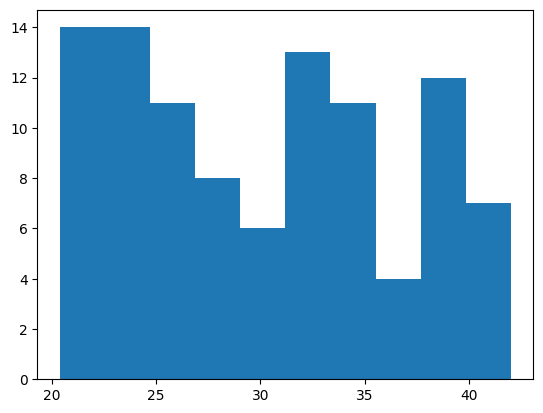

In [3]:
import matplotlib.pyplot as plt

plt.hist(df["Temperature_C"])
plt.show()

In [4]:
# import numpy as np

# df["Humidity"] = np.random.randint(40,95,len(df))
# df["Transport_Time_Hours"] = np.random.randint(1,12,len(df))
# df["Storage_Days"] = np.random.randint(0,10,len(df))

np.random.seed(42)
df["Humidity"] = np.random.randint(40,95,len(df))
df["Transport_Time_Hours"] = np.random.randint(1,12,len(df))
df["Storage_Days"] = np.random.randint(0,10,len(df))
df["Heatwave_Alert"] = np.where(df["Temperature_C"]>35,"Yes","No")
df["Farmer_Experience"] = np.random.choice(["Beginner","Intermediate","Expert"],len(df))
df.head()

,Record_ID,Date,Location,Crop_Type,Temperature_C,Spoilage_Observed,Storage_Available,Humidity,Transport_Time_Hours,Storage_Days,Heatwave_Alert,Farmer_Experience
0,1,2025-02-02,Village_C,Tomato,32.6,Yes,Yes,78,8,0,No,Beginner
1,2,2025-02-03,Village_A,Onion,27.2,Yes,Yes,91,10,0,No,Beginner
2,3,2025-02-04,Village_C,Onion,21.1,Yes,No,68,9,9,No,Beginner
3,4,2025-02-05,Village_B,Wheat,34.9,No,Yes,54,9,3,No,Beginner
4,5,2025-02-06,Village_C,Potato,32.5,Yes,No,82,1,6,No,Intermediate


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
df.to_csv("updated_dataset.csv",index=False)
df_ml=df.copy()
for col in df_ml.columns:
    if df_ml[col].dtype=="object":
        le=LabelEncoder()
        df_ml[col]=le.fit_transform(df_ml[col].astype(str))
X=df_ml.drop("Spoilage_Observed",axis=1)
y=df_ml["Spoilage_Observed"]